C:\Users\licet\AppData\Roaming\Python\Python311\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


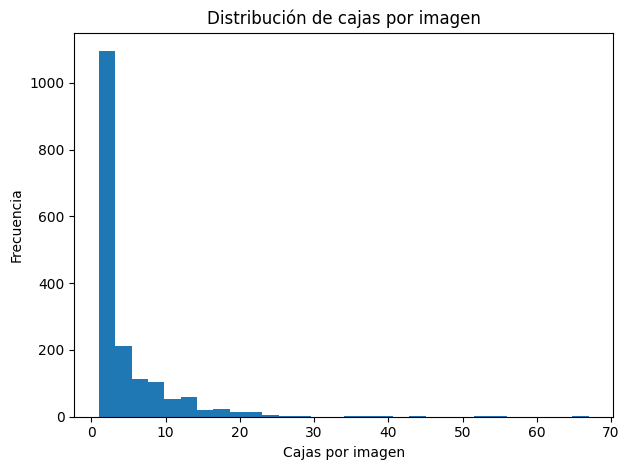

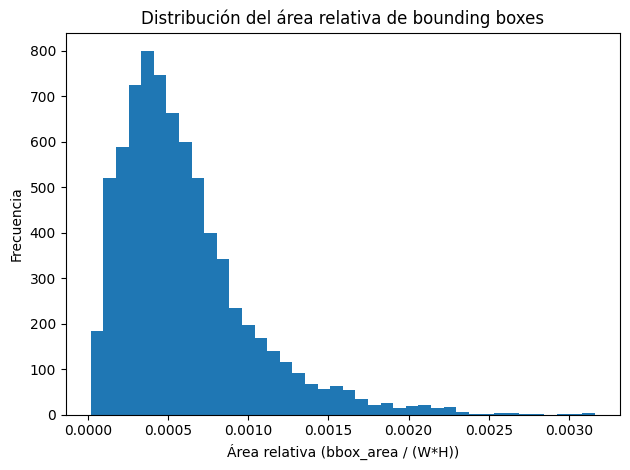

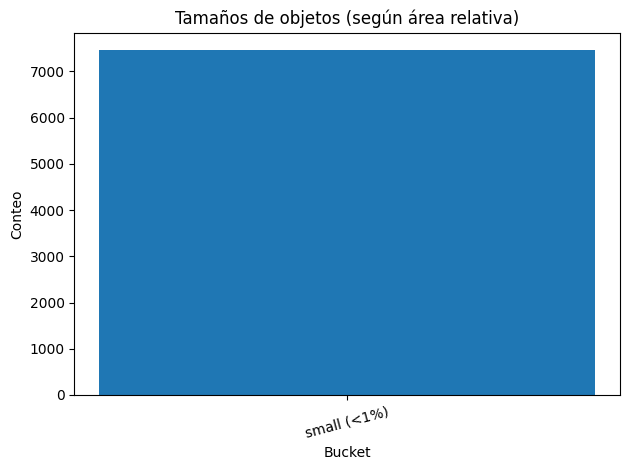

In [1]:
# === EDA y gráficas a partir de JSON de anotaciones (COCO-like o lista custom) ===
import json, math, os
from collections import defaultdict, Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from PIL import Image
from pathlib import Path
from matplotlib import colors as mcolors
from IPython.display import display

# Ruta subframes
PATH_JSON = "general_dataset/general_dataset/groundtruth/json/sub_frames/train_subframes_A_B_E_K_WH_WB.json"
BASE_DIR_IMAGES = "general_dataset/general_dataset/train_subframes"
# Rutas IMAGENES ORIGINALES
BASE_DIR_IMAGES_BIG = "general_dataset/general_dataset/train"  
PATH_JSON_BIG  = "general_dataset/general_dataset/groundtruth/json/big_size/train_big_size_A_B_E_K_WH_WB.json"

with open(PATH_JSON, "r", encoding="utf-8") as f:
    data = json.load(f)

def is_coco(d):
    return isinstance(d, dict) and all(k in d for k in ["images", "annotations", "categories"])

def normalize_to_coco_like(d):
    """
    Devuelve (images_df, ann_df, cats_df) con columnas estandarizadas:
      images_df: [image_id, file_name, width, height]
      ann_df:    [ann_id, image_id, category_id, bbox (x,y,w,h), area]
      cats_df:   [category_id, name]
    Soporta COCO 'clásico' o listas custom con claves comunes.
    """
    if is_coco(d):
        images_df = pd.DataFrame(d["images"]).rename(columns={"id": "image_id"})
        ann_df    = pd.DataFrame(d["annotations"]).rename(columns={"id": "ann_id"})
        cats_df   = pd.DataFrame(d["categories"]).rename(columns={"id": "category_id"})
        # Área, si falta, la derivamos del bbox
        if "area" not in ann_df.columns and "bbox" in ann_df.columns:
            ann_df["area"] = ann_df["bbox"].apply(
                lambda b: float(b[2]) * float(b[3]) if isinstance(b, (list, tuple)) and len(b) >= 4 else np.nan
            )
        # Asegurar columnas mínimas
        for col in ["file_name", "width", "height"]:
            if col not in images_df.columns:
                images_df[col] = None
        if "bbox" not in ann_df.columns:
            ann_df["bbox"] = None
        return (
            images_df[["image_id", "file_name", "width", "height"]],
            ann_df[["ann_id", "image_id", "category_id", "bbox", "area"]],
            cats_df[["category_id", "name"]],
        )

    # Estructuras tipo lista (custom)
    assert isinstance(d, list), "Estructura JSON no reconocida"
    images, anns, cats = [], [], {}
    next_img_id, next_ann_id = 1, 1
    for rec in d:
        file_name = rec.get("file_name") or rec.get("filename") or rec.get("image") or rec.get("path") or rec.get("name")
        width  = rec.get("width") or rec.get("img_width") or rec.get("W")
        height = rec.get("height") or rec.get("img_height") or rec.get("H")
        image_id = rec.get("image_id") or next_img_id
        if "image_id" not in rec:
            next_img_id += 1
        images.append({"image_id": image_id, "file_name": file_name, "width": width, "height": height})

        ann_list = rec.get("annotations") or rec.get("ann") or rec.get("labels") or rec.get("objects") or []
        for a in ann_list:
            bbox = a.get("bbox")
            if bbox is None:
                if all(k in a for k in ("x", "y", "w", "h")):
                    bbox = [a["x"], a["y"], a["w"], a["h"]]
                elif all(k in a for k in ("xmin", "ymin", "xmax", "ymax")):
                    bbox = [a["xmin"], a["ymin"], a["xmax"] - a["xmin"], a["ymax"] - a["ymin"]]
            cname = a.get("category") or a.get("class") or a.get("label") or a.get("species")
            if cname is None and "category_id" in a:
                cname = str(a["category_id"])
            if cname not in cats:
                cats[cname] = len(cats) + 1
            cid = cats[cname]
            area = a.get("area")
            if area is None and isinstance(bbox, (list, tuple)) and len(bbox) >= 4:
                area = float(bbox[2]) * float(bbox[3])
            anns.append({"ann_id": next_ann_id, "image_id": image_id, "category_id": cid, "bbox": bbox, "area": area})
            next_ann_id += 1

    images_df = pd.DataFrame(images)
    ann_df    = pd.DataFrame(anns)
    cats_df   = pd.DataFrame([{"category_id": cid, "name": name} for name, cid in cats.items()])
    for col in ["file_name", "width", "height"]:
        if col not in images_df.columns:
            images_df[col] = None
    if "bbox" not in ann_df.columns:
        ann_df["bbox"] = None
    if "area" not in ann_df.columns:
        ann_df["area"] = np.nan
    return (
        images_df[["image_id", "file_name", "width", "height"]],
        ann_df[["ann_id", "image_id", "category_id", "bbox", "area"]],
        cats_df[["category_id", "name"]],
    )

images_df, ann_df, cats_df = normalize_to_coco_like(data)

# === Área relativa por bbox (si tenemos width/height por imagen) ===
if images_df["width"].notna().all() and images_df["height"].notna().all():
    img_sizes = images_df.set_index("image_id")[["width", "height"]].to_dict("index")
    def rel_area(row):
        wh = img_sizes.get(row["image_id"])
        if not wh or pd.isna(row["area"]):
            return np.nan
        denom = float(wh["width"]) * float(wh["height"])
        return (float(row["area"]) / denom) if denom > 0 else np.nan
    ann_df["rel_area"] = ann_df.apply(rel_area, axis=1)
else:
    ann_df["rel_area"] = np.nan

# === Cajas por imagen ===
boxes_per_image = ann_df.groupby("image_id").size().rename("boxes").reset_index()

# === Buckets de tamaño según área relativa ===
def size_bucket(ra):
    if pd.isna(ra):
        return "unknown"
    if ra < 0.01:
        return "small (<1%)"
    if ra < 0.05:
        return "medium (1–5%)"
    return "large (≥5%)"

ann_df["size_bucket"] = ann_df["rel_area"].apply(size_bucket)
size_counts = ann_df["size_bucket"].value_counts().rename_axis("bucket").reset_index(name="count")

# ---------------------------
#   GRÁFICAS (Matplotlib)
# ---------------------------

# 1) Histograma: cajas por imagen
plt.figure()
plt.hist(boxes_per_image["boxes"], bins=30)
plt.title("Distribución de cajas por imagen")
plt.xlabel("Cajas por imagen")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

# 2) Histograma: área relativa de bboxes
rel_area_clean = ann_df["rel_area"].dropna()
if len(rel_area_clean):
    plt.figure()
    plt.hist(rel_area_clean, bins=40)
    plt.title("Distribución del área relativa de bounding boxes")
    plt.xlabel("Área relativa (bbox_area / (W*H))")
    plt.ylabel("Frecuencia")
    plt.tight_layout()
    plt.show()

# 3) Barras: conteo por bucket de tamaños
plt.figure()
size_counts_sorted = size_counts.sort_values("count", ascending=False)
plt.bar(size_counts_sorted["bucket"], size_counts_sorted["count"])
plt.title("Tamaños de objetos (según área relativa)")
plt.xlabel("Bucket")
plt.ylabel("Conteo")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()



🧬 Top 10 imágenes con mayor número de especies (con lista de especies):


,image_id,num_species,species_list,boxes_total,file_name,width,height
0,696,4,"[Alcelaphinae, Buffalo, Kob, Warthog]",6,S_10_05_16_DSC00794.JPG,6000,4000
1,504,3,"[Alcelaphinae, Kob, Warthog]",45,S_08_05_16_DSC00670.JPG,6000,4000
2,503,3,"[Alcelaphinae, Kob, Warthog]",28,S_08_05_16_DSC00669.JPG,6000,4000
3,44,3,"[Buffalo, Warthog, Waterbuck]",12,L_07_05_16_DSC00151.JPG,6000,4000
4,579,3,"[Alcelaphinae, Kob, Warthog]",11,S_09_05_16_DSC00830.JPG,6000,4000
5,95,3,"[Alcelaphinae, Kob, Warthog]",6,L_07_05_16_DSC00564.JPG,6000,4000
6,94,3,"[Alcelaphinae, Kob, Warthog]",5,L_07_05_16_DSC00563.JPG,6000,4000
7,333,2,"[Alcelaphinae, Kob]",69,L_10_05_16_DSC01571.JPG,6000,4000
8,372,2,"[Buffalo, Warthog]",49,L_11_05_16_DSC01109.JPG,6000,4000
9,621,2,"[Kob, Warthog]",48,S_09_05_16_DSC00946.JPG,6000,4000


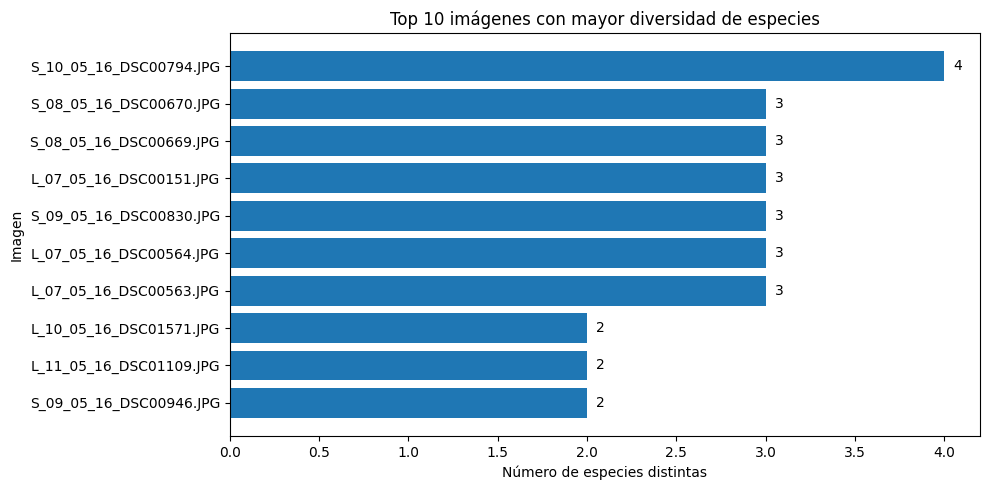

📊 Resumen:


,metric,value
0,num_images,928.000000
1,num_annotations,7461.000000
2,num_categories,6.000000
3,boxes_per_image_mean,8.039871
4,boxes_per_image_max,123.000000
5,mean_rel_area,0.000105



🐾 Conteo por categoría:


,category_id,count,category,pct
0,6,2443,Elephant,32.74
1,3,1745,Kob,23.39
2,1,1701,Alcelaphinae,22.80
3,2,1080,Buffalo,14.48
4,4,323,Warthog,4.33
5,5,169,Waterbuck,2.27


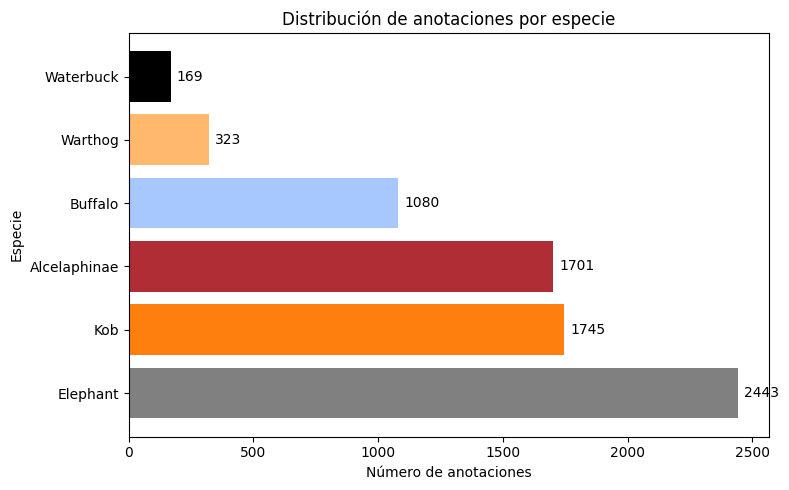

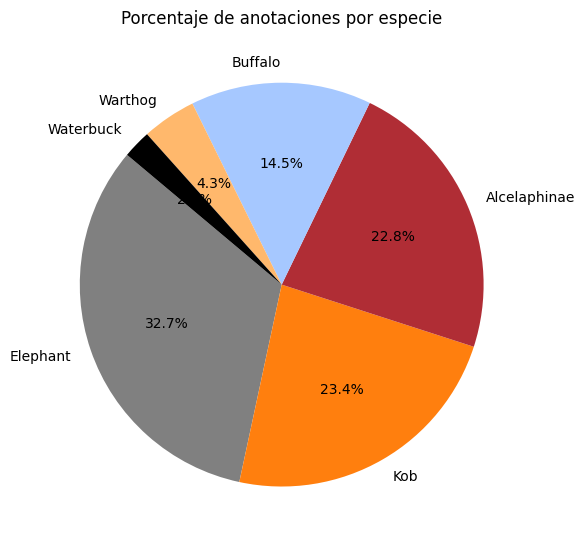


📈 Top 15 imágenes con más boxes:


,image_id,file_name,boxes,width,height
0,228,L_09_05_16_DSC10034.JPG,123,6000,4000
1,418,L_11_05_16_DSC01346.JPG,122,6000,4000
2,383,L_11_05_16_DSC01143.JPG,109,6000,4000
3,430,L_11_05_16_DSC01397.JPG,89,6000,4000
4,958,220a276f8e6fa93834f053cfe9b1c8186f43feb0.JPG,81,5496,3670
5,137,L_07_05_16_DSC00701.JPG,70,6000,4000
6,333,L_10_05_16_DSC01571.JPG,69,6000,4000
7,258,L_09_05_16_DSC10151.JPG,61,6000,4000
8,259,L_09_05_16_DSC10152.JPG,58,6000,4000
9,379,L_11_05_16_DSC01131.JPG,57,6000,4000



🏷️ Buckets de tamaño:


,bucket,count
0,small (<1%),7461



📘 Excel consolidado guardado en:
C:\Users\licet\ProyectoGrado MAIA\eda_out_unificado\analysis_full.xlsx


In [15]:
# ============================================================
# UNIFICADO: ANÁLISIS DE IMÁGENES ORIGINALES + SUBFRAMES + GRÁFICOS
# ============================================================
OUT_DIR = "eda_out_unificado"
os.makedirs(OUT_DIR, exist_ok=True)

# ---------- Paleta de colores fija ----------
species_colors_hex = {
    "buffalo":    "#A6C8FF",  # azul claro
    "elephant":   "#808080",  # gris
    "kob":        "#FF7F0E",  # naranja brillante
    "alcelaphinae":       "#B02D35",  # Rojo
    "warthog":    "#FFB86C",  # naranja claro
    "waterbuck":  "#000000"   # negro
}
species_colors = {k: mcolors.to_rgba(v) for k, v in species_colors_hex.items()}

# ---------- Helpers ----------
def is_coco(d):
    return isinstance(d, dict) and all(k in d for k in ["images", "annotations", "categories"])

def normalize_to_coco_like(d):
    """Devuelve DataFrames COCO-like."""
    if is_coco(d):
        images_df = pd.DataFrame(d["images"]).rename(columns={"id":"image_id"})
        ann_df    = pd.DataFrame(d.get("annotations", [])).rename(columns={"id":"ann_id"})
        cats_df   = pd.DataFrame(d.get("categories", [])).rename(columns={"id":"category_id"})
    else:
        raise ValueError("El JSON no tiene formato COCO.")

    if "area" not in ann_df.columns and "bbox" in ann_df.columns:
        ann_df["area"] = ann_df["bbox"].apply(lambda b: b[2]*b[3] if isinstance(b,(list,tuple)) and len(b)>=4 else np.nan)
    for col in ["file_name","width","height"]:
        if col not in images_df.columns:
            images_df[col] = None
    if "bbox" not in ann_df.columns: ann_df["bbox"] = None
    if "area" not in ann_df.columns: ann_df["area"] = np.nan
    if "name" not in cats_df.columns:
        cats_df["name"] = cats_df["category_id"].astype(str)
    return (
        images_df[["image_id","file_name","width","height"]],
        ann_df[["ann_id","image_id","category_id","bbox","area"]],
        cats_df[["category_id","name"]]
    )

def size_bucket(rel_area):
    if pd.isna(rel_area): return "unknown"
    if rel_area < 0.01:   return "small (<1%)"
    if rel_area < 0.05:   return "medium (1–5%)"
    return "large (≥5%)"

def stem_base(fname: str) -> str:
    return Path(fname).stem.split("_S")[0]

# ---------- Carga JSONs ----------
with open(PATH_JSON_BIG, "r", encoding="utf-8") as f:
    big_data = json.load(f)
with open(PATH_JSON, "r", encoding="utf-8") as f:
    sub_data = json.load(f)

big_imgs, big_anns, big_cats = normalize_to_coco_like(big_data)
sub_imgs, sub_anns, sub_cats = normalize_to_coco_like(sub_data)

# ---------- Unificación de categorías ----------
cats_df = pd.concat([big_cats, sub_cats]).drop_duplicates("category_id", keep="first")
cat_map = dict(zip(cats_df["category_id"], cats_df["name"]))

# ---------- Mapear subframes → originales ----------
big_imgs["base_stem"] = big_imgs["file_name"].map(stem_base)
sub_imgs["base_stem"] = sub_imgs["file_name"].map(stem_base)

full_idx = big_imgs.set_index("base_stem")[["image_id","width","height"]].to_dict("index")
sub_idx  = sub_imgs.set_index("image_id")[["base_stem","width","height"]].to_dict("index")

# ---------- Reproyección de anotaciones ----------
projected_rows = []
next_ann_id = 1
for _, a in sub_anns.iterrows():
    s_info = sub_idx.get(a["image_id"])
    if not s_info: continue
    base = s_info["base_stem"]
    f_info = full_idx.get(base)
    if not f_info: continue
    projected_rows.append({
        "ann_id": next_ann_id,
        "image_id": f_info["image_id"],
        "category_id": a["category_id"],
        "bbox": a["bbox"],
        "area": (a["bbox"][2]*a["bbox"][3]) if isinstance(a["bbox"], (list,tuple)) and len(a["bbox"])>=4 else np.nan
    })
    next_ann_id += 1

# Combinar anotaciones
ann_df = pd.DataFrame(projected_rows)
images_df = big_imgs.copy()

# ---------- Calcular área relativa ----------
if not ann_df.empty and images_df["width"].notna().all() and images_df["height"].notna().all():
    wh = images_df.set_index("image_id")[["width","height"]].to_dict("index")
    def _rel(row):
        info = wh.get(row["image_id"])
        if not info or pd.isna(row["area"]): return np.nan
        denom = float(info["width"]) * float(info["height"])
        return float(row["area"])/denom if denom>0 else np.nan
    ann_df["rel_area"] = ann_df.apply(_rel, axis=1)
else:
    ann_df["rel_area"] = np.nan

# ---------- Métricas ----------
boxes_per_image = ann_df.groupby("image_id").size().rename("boxes").reset_index()
rel_clean = ann_df["rel_area"].dropna()

summary_df = pd.DataFrame([
    {"metric":"num_images", "value": len(images_df)},
    {"metric":"num_annotations", "value": len(ann_df)},
    {"metric":"num_categories", "value": len(cats_df)},
    {"metric":"boxes_per_image_mean", "value": boxes_per_image["boxes"].mean() if len(boxes_per_image) else 0.0},
    {"metric":"boxes_per_image_max", "value": boxes_per_image["boxes"].max() if len(boxes_per_image) else 0},
    {"metric":"mean_rel_area", "value": rel_clean.mean() if len(rel_clean) else np.nan},
])

# ---------- Conteos ----------
cat_counts = ann_df["category_id"].value_counts().rename_axis("category_id").reset_index(name="count")
cat_counts["category"] = cat_counts["category_id"].map(cat_map)
cat_counts["pct"] = (cat_counts["count"]/cat_counts["count"].sum()*100).round(2)
cat_counts = cat_counts.sort_values("count", ascending=False)

# ---------- Top imágenes ----------
top_images = boxes_per_image.sort_values("boxes", ascending=False).head(15)
top_images = top_images.merge(images_df, on="image_id", how="left")[["image_id","file_name","boxes","width","height"]]

# ---------- Buckets ----------
ann_df["size_bucket"] = ann_df["rel_area"].apply(size_bucket)
size_counts = ann_df["size_bucket"].value_counts().rename_axis("bucket").reset_index(name="count")
cat_size_crosstab = pd.crosstab(ann_df["size_bucket"], ann_df["category_id"]).rename(columns=cat_map)

# ---------- Muestra ----------
sample_anns = ann_df.sample(min(50, len(ann_df)), random_state=42).copy()
sample_anns["category"] = sample_anns["category_id"].map(cat_map)
sample_anns = sample_anns[["ann_id","image_id","category","bbox","area","rel_area","size_bucket"]]

# ---------- TOP 10: Imágenes con mayor número de especies ----------
# especies distintas por imagen
species_per_image = (
    ann_df.groupby("image_id")["category_id"]
          .nunique()
          .rename("num_species")
          .reset_index()
)

# lista de especies presentes por imagen (por nombre)
species_list_per_image = (
    ann_df.groupby("image_id")["category_id"]
          .apply(lambda s: sorted({cat_map.get(int(cid), str(cid)) for cid in s}))
          .rename("species_list")
          .reset_index()
)

# (opcional) cajas totales por imagen para desempate
boxes_per_image_all = (
    ann_df.groupby("image_id")
          .size()
          .rename("boxes_total")
          .reset_index()
)

# combinar con metadatos de imagen
top_multi_species = (
    species_per_image.merge(species_list_per_image, on="image_id", how="left")
                     .merge(boxes_per_image_all, on="image_id", how="left")
                     .merge(images_df[["image_id","file_name","width","height"]], on="image_id", how="left")
                     .sort_values(["num_species","boxes_total"], ascending=[False, False])
                     .head(10)
                     .reset_index(drop=True)
)

# guardar CSV
top10_path = os.path.join(OUT_DIR, "top10_images_most_species.csv")
top_multi_species.to_csv(top10_path, index=False)

# mostrar en notebook
print("\n🧬 Top 10 imágenes con mayor número de especies (con lista de especies):")
display(top_multi_species)

# gráfico de barras (número de especies por imagen)
plt.figure(figsize=(10, 5))
plt.barh(top_multi_species["file_name"], top_multi_species["num_species"])
plt.gca().invert_yaxis()
plt.xlabel("Número de especies distintas")
plt.ylabel("Imagen")
plt.title("Top 10 imágenes con mayor diversidad de especies")
for i, v in enumerate(top_multi_species["num_species"]):
    plt.text(v + 0.05, i, str(v), va="center")
plt.tight_layout()
plt.show()


# ---------- Guardar ----------
xlsx_path = os.path.join(OUT_DIR, "analysis_full.xlsx")
with pd.ExcelWriter(xlsx_path, engine="openpyxl") as writer:
    summary_df.to_excel(writer, sheet_name="summary", index=False)
    cat_counts.to_excel(writer, sheet_name="category_counts", index=False)
    boxes_per_image.to_excel(writer, sheet_name="boxes_per_image", index=False)
    top_images.to_excel(writer, sheet_name="top_images", index=False)
    size_counts.to_excel(writer, sheet_name="size_buckets", index=False)
    cat_size_crosstab.to_excel(writer, sheet_name="cat_x_size")
    images_df.to_excel(writer, sheet_name="images", index=False)
    ann_df.to_excel(writer, sheet_name="annotations", index=False)
    cats_df.to_excel(writer, sheet_name="categories", index=False)
    sample_anns.to_excel(writer, sheet_name="sample_50", index=False)
    top_multi_species.to_excel(writer, sheet_name="top10_most_species", index=False)


# ---------- Visualizaciones ----------
print("📊 Resumen:")
display(summary_df)
print("\n🐾 Conteo por categoría:")
display(cat_counts)

# Paleta de colores según especie
color_list = [species_colors.get(cat.lower(), (0.5,0.5,0.5,1)) for cat in cat_counts["category"].str.lower()]

# --- Gráfico de barras ---
plt.figure(figsize=(8, 5))
plt.barh(cat_counts["category"], cat_counts["count"], color=color_list)
plt.xlabel("Número de anotaciones")
plt.ylabel("Especie")
plt.title("Distribución de anotaciones por especie")
for i, v in enumerate(cat_counts["count"]):
    plt.text(v + max(cat_counts["count"])*0.01, i, str(v), va='center')
plt.tight_layout()
plt.show()

# --- Gráfico circular ---
plt.figure(figsize=(6, 6))
plt.pie(cat_counts["count"], labels=cat_counts["category"],
        autopct="%1.1f%%", colors=color_list, startangle=140)
plt.title("Porcentaje de anotaciones por especie")
plt.tight_layout()
plt.show()

# ---------- Reporte final ----------
print("\n📈 Top 15 imágenes con más boxes:")
display(top_images)
print("\n🏷️ Buckets de tamaño:")
display(size_counts)
print("\n📘 Excel consolidado guardado en:")
print(os.path.abspath(xlsx_path))


C:\Users\licet\AppData\Local\Temp\ipykernel_1044\354826408.py:77: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", max(20, len(cats_df)))


📷 Procesando imagen: S_10_05_16_DSC00794.JPG


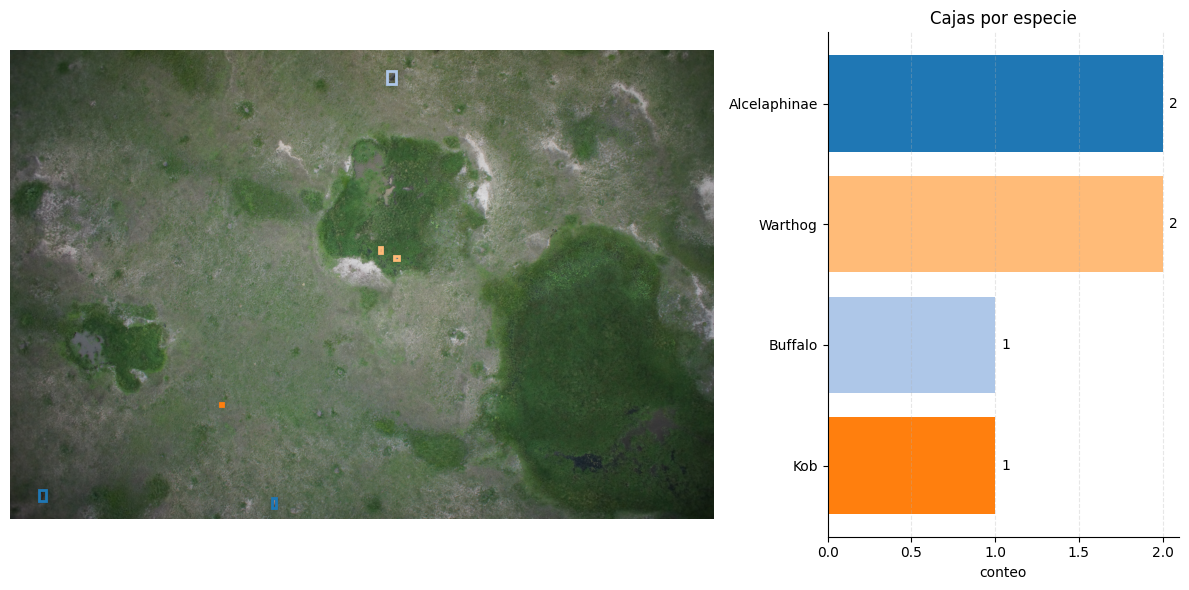

In [8]:
# ---------- VISUALIZACION IMAGEN ORIGINAL CON ANOTACIONES ----------
def is_coco(d):
    return isinstance(d, dict) and all(k in d for k in ["images", "annotations", "categories"])

def normalize_to_coco_like(d):
    """
    Devuelve (images_df, ann_df, cats_df) con columnas estandarizadas:
      images_df: [image_id, file_name, width, height]
      ann_df:    [ann_id, image_id, category_id, bbox(x,y,w,h), score?]
      cats_df:   [category_id, name]
    Soporta COCO 'clásico' o listas custom con claves comunes.
    """
    if is_coco(d):
        images_df = pd.DataFrame(d["images"]).rename(columns={"id": "image_id"})
        ann_df    = pd.DataFrame(d["annotations"]).rename(columns={"id": "ann_id"})
        cats_df   = pd.DataFrame(d["categories"]).rename(columns={"id": "category_id"})
        # Asegurar columnas mínimas
        for col in ["file_name","width","height"]:
            if col not in images_df.columns: images_df[col] = None
        if "bbox" not in ann_df.columns: ann_df["bbox"] = None
        if "score" not in ann_df.columns: ann_df["score"] = np.nan
        return (
            images_df[["image_id","file_name","width","height"]],
            ann_df[["ann_id","image_id","category_id","bbox","score"]],
            cats_df[["category_id","name"]],
        )

    # Estructuras tipo lista (custom)
    images, anns, cats = [], [], {}
    next_img_id, next_ann_id = 1, 1
    for rec in d:
        file_name = rec.get("file_name") or rec.get("filename") or rec.get("image") or rec.get("path") or rec.get("name")
        width  = rec.get("width")  or rec.get("img_width")  or rec.get("W")
        height = rec.get("height") or rec.get("img_height") or rec.get("H")
        image_id = rec.get("image_id") or next_img_id
        if "image_id" not in rec: next_img_id += 1
        images.append({"image_id": image_id, "file_name": file_name, "width": width, "height": height})

        ann_list = rec.get("annotations") or rec.get("ann") or rec.get("labels") or rec.get("objects") or []
        for a in ann_list:
            bbox = a.get("bbox")
            if bbox is None:
                if all(k in a for k in ("x","y","w","h")):
                    bbox = [a["x"], a["y"], a["w"], a["h"]]
                elif all(k in a for k in ("xmin","ymin","xmax","ymax")):
                    bbox = [a["xmin"], a["ymin"], a["xmax"]-a["xmin"], a["ymax"]-a["ymin"]]
            cname = a.get("category") or a.get("class") or a.get("label") or a.get("species")
            if cname is None and "category_id" in a:  # fallback
                cname = str(a["category_id"])
            if cname not in cats: cats[cname] = len(cats)+1
            cid = cats[cname]
            score = a.get("score", np.nan)
            anns.append({"ann_id": next_ann_id, "image_id": image_id, "category_id": cid, "bbox": bbox, "score": score})
            next_ann_id += 1

    images_df = pd.DataFrame(images)
    ann_df    = pd.DataFrame(anns)
    cats_df   = pd.DataFrame([{"category_id": cid, "name": name} for name, cid in cats.items()])
    for col in ["file_name","width","height"]:
        if col not in images_df.columns: images_df[col] = None
    if "bbox" not in ann_df.columns: ann_df["bbox"] = None
    if "score" not in ann_df.columns: ann_df["score"] = np.nan
    return (
        images_df[["image_id","file_name","width","height"]],
        ann_df[["ann_id","image_id","category_id","bbox","score"]],
        cats_df[["category_id","name"]],
    )

# ---------- Carga de anotaciones ----------
with open(PATH_JSON_BIG, "r", encoding="utf-8") as f:
    data = json.load(f)

images_df, ann_df, cats_df = normalize_to_coco_like(data)
cat_map = dict(zip(cats_df["category_id"], cats_df["name"]))

# Colores por categoría (estables). tab20 cubre hasta 20 clases; si hay más, rota.
cmap = plt.cm.get_cmap("tab20", max(20, len(cats_df)))
cat_colors = {cid: cmap(i % cmap.N) for i, cid in enumerate(sorted(cats_df["category_id"].tolist()))}

# ---------- Helpers ----------
def _safe_join(base, name):
    """Une rutas evitando conflictos: si file_name tiene subcarpetas/absoluto, se respeta."""
    if not base:
        return name
    if os.path.isabs(name) or ("/" in name or "\\" in name):
        return name
    return os.path.join(base, name)

def _ensure_xywh(bbox):
    """Convierte bbox potencialmente en [xmin,ymin,xmax,ymax] a [x,y,w,h] si hace falta."""
    if bbox is None or (isinstance(bbox, (list, tuple)) and len(bbox) < 4):
        return None
    b = list(bbox)
    # Si w/h no son positivos, interpretamos como xyxy -> xywh
    if b[2] <= 0 or b[3] <= 0:
        x, y, xmax, ymax = b[0], b[1], b[2], b[3]
        return [x, y, xmax - x, ymax - y]
    return b[:4]

# ---------- Visualización (imagen + barras de conteo) ----------
def visualize_original_with_counts_by_image_id(image_id, linewidth=2, barh=True):
    row = images_df[images_df["image_id"] == image_id]
    assert len(row) == 1, f"image_id {image_id} no encontrado"
    file_name = row.iloc[0]["file_name"]
    return visualize_original_with_counts_by_filename(file_name, image_id=image_id, linewidth=linewidth, barh=barh)

def visualize_original_with_counts_by_filename(file_name, image_id=None, linewidth=2, barh=True):
    # Resolver image_id si no se pasó
    print(f"📷 Procesando imagen: {file_name}")
    if image_id is None:
        row = images_df[images_df["file_name"] == file_name]
        assert len(row) == 1, f"file_name {file_name} no encontrado o no es único"
        image_id = row.iloc[0]["image_id"]

    # Construir ruta de imagen original en BASE_DIR_IMAGES_BIG
    img_path = _safe_join(BASE_DIR_IMAGES_BIG, file_name)
    # Normalización de separadores por si el file_name trae backslashes
    if not os.path.exists(img_path):
        img_path_alt = img_path.replace("\\", "/")
        if os.path.exists(img_path_alt):
            img_path = img_path_alt
        else:
            raise FileNotFoundError(f"No se encontró la imagen: {img_path}")

    # Cargar imagen
    img = Image.open(img_path).convert("RGB")

    # Filtrar anotaciones de esa imagen
    anns = ann_df[ann_df["image_id"] == image_id].copy()
    anns["category_name"] = anns["category_id"].map(cat_map)

    # Conteo por especie (por nombre legible)
    counts = anns["category_name"].value_counts().rename_axis("species").reset_index(name="count")

    # Figura con 2 ejes: izquierda imagen, derecha barras
    fig, (ax_img, ax_cnt) = plt.subplots(
        1, 2, figsize=(12, 6), gridspec_kw={"width_ratios": [4, 2]}
    )

    # --- Izquierda: imagen con bboxes (sin texto, sin relleno, sin transparencia) ---
    ax_img.imshow(img)
    ax_img.set_axis_off()

    for _, a in anns.iterrows():
        bbox = _ensure_xywh(a["bbox"])
        if bbox is None:
            continue
        x, y, w, h = bbox
        x = max(0, x); y = max(0, y)
        w = max(0, w); h = max(0, h)
        cid = a["category_id"]
        color = cat_colors.get(cid, (1, 0, 0, 1))  # borde rojo si falta color asignado
        rect = Rectangle((x, y), w, h, fill=False, edgecolor=color, linewidth=linewidth)
        ax_img.add_patch(rect)
        # Importante: NO dibujar texto/etiquetas sobre la imagen

    # --- Derecha: barras de conteo por especie ---
    ax_cnt.set_title("Cajas por especie")
    if counts.empty:
        ax_cnt.text(0.5, 0.5, "Sin anotaciones", ha="center", va="center")
        ax_cnt.set_axis_off()
    else:
        # Ordenar para barh
        counts = counts.sort_values("count", ascending=True)
        species = counts["species"].tolist()
        values = counts["count"].tolist()
        # Colores en el mismo orden de species
        # (obtenemos el category_id correspondiente a cada nombre)
        name_to_id = {v: k for k, v in cat_map.items()}
        colors = [cat_colors.get(name_to_id.get(s), (0.5, 0.5, 0.5, 1.0)) for s in species]

        if barh:
            ax_cnt.barh(species, values, color=colors)
            ax_cnt.set_xlabel("conteo")
        else:
            ax_cnt.bar(species, values, color=colors)
            ax_cnt.set_ylabel("conteo")
            ax_cnt.set_xticklabels(species, rotation=45, ha="right")

        # Mostrar valores al final de cada barra
        if barh:
            vmax = max(values) if len(values) else 0
            for i, v in enumerate(values):
                ax_cnt.text(v + (0.02*vmax if vmax>0 else 0.1), i, str(v), va="center")
        else:
            vmax = max(values) if len(values) else 0
            for i, v in enumerate(values):
                ax_cnt.text(i, v + (0.02*vmax if vmax>0 else 0.1), str(v), ha="center")

        ax_cnt.grid(axis="x", linestyle="--", alpha=0.3)
        ax_cnt.spines['top'].set_visible(False)
        ax_cnt.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.show()

# ----------------------------
# USO (elige una de estas formas):
# visualize_original_with_counts_by_image_id(75)
# visualize_original_with_counts_by_filename("L_07_05_16_DSC00563_S1.JPG")
# ----------------------------
visualize_original_with_counts_by_image_id(696)

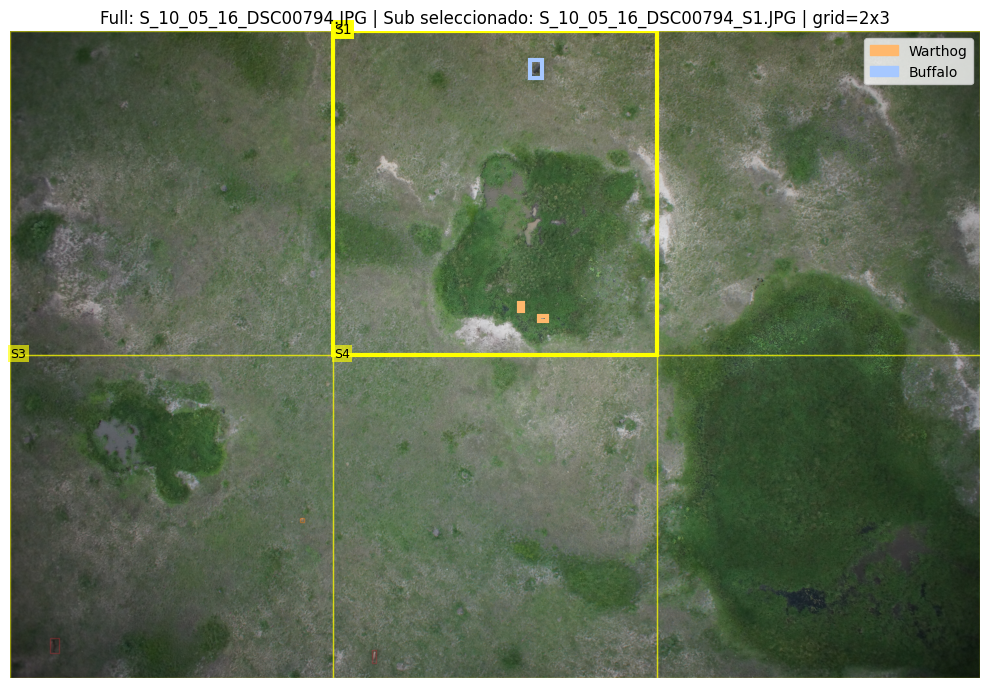

📋 Resumen de subframes y anotaciones:
- S_10_05_16_DSC00794_S1.JPG (S1): 3 → {'Warthog': 2, 'Buffalo': 1}
- S_10_05_16_DSC00794_S3.JPG (S3): 2 → {'Kob': 1, 'Alcelaphinae': 1}
- S_10_05_16_DSC00794_S4.JPG (S4): 1 → {'Alcelaphinae': 1}


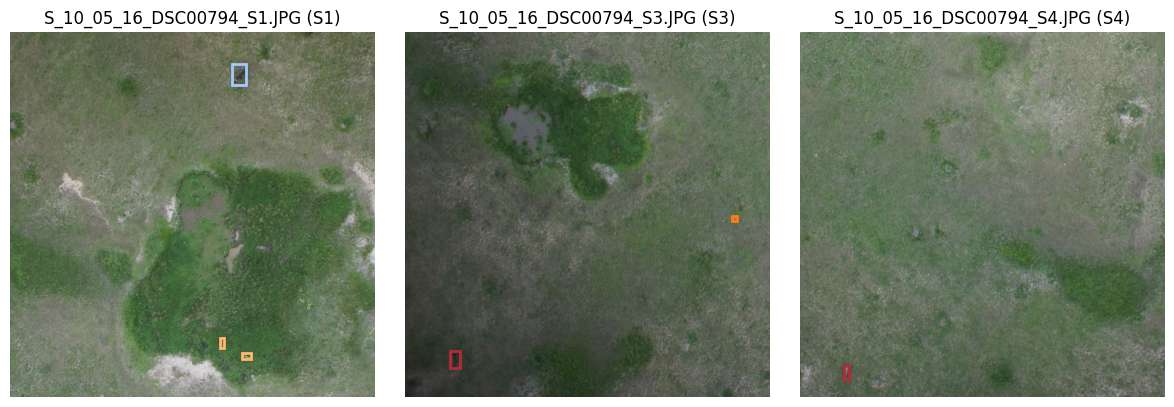

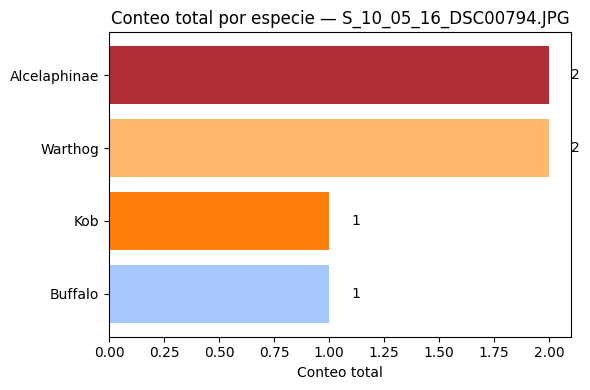

In [17]:
# ---------- VISUALIZACION IMAGEN ORIGINAL CON SUBFRAMES Y ANOTACIONES DE LO SUBFRAMES ----------
species_colors = {k.lower(): mcolors.to_rgba(v) for k, v in species_colors_hex.items()}

def stem_base(fname: str) -> str:
    return Path(fname).stem.split("_S")[0]

def extract_S_index(file_name: str):
    s = Path(file_name).stem
    if "_S" in s:
        try: return int(s.split("_S")[-1])
        except: return None
    return None

def bbox_to_xywh(b):
    if b is None or not isinstance(b,(list,tuple)) or len(b)<4:
        return None
    x,y,w,h = b[0], b[1], b[2], b[3]
    # si viniera en xyxy, lo corregimos
    if w <= 0 or h <= 0:
        xmin,ymin,xmax,ymax = b
        return [xmin, ymin, max(0, xmax-xmin), max(0, ymax-ymin)]
    return [x,y,w,h]

def safe_join(base, name):
    if not base or os.path.isabs(name) or ("/" in name or "\\" in name):
        return name
    return os.path.join(base, name)

def is_coco(d):
    return isinstance(d, dict) and all(k in d for k in ["images","annotations","categories"])

def load_coco_like(path_json):
    with open(path_json, "r", encoding="utf-8") as f:
        data = json.load(f)
    assert is_coco(data), f"{path_json} no es COCO-like"
    imgs = pd.DataFrame(data["images"]).rename(columns={"id":"image_id"})
    anns = pd.DataFrame(data.get("annotations", [])).rename(columns={"id":"ann_id"})
    cats = pd.DataFrame(data.get("categories", [])).rename(columns={"id":"category_id"})
    if "bbox" not in anns.columns: anns["bbox"] = None
    if "area" not in anns.columns and "bbox" in anns.columns:
        anns["area"] = anns["bbox"].apply(lambda b: b[2]*b[3] if isinstance(b,(list,tuple)) and len(b)>=4 else np.nan)
    for col in ["file_name","width","height"]:
        if col not in imgs.columns: imgs[col] = None
    if "name" not in cats.columns: cats["name"] = cats["category_id"].astype(str)
    return (
        imgs[["image_id","file_name","width","height"]],
        anns[["ann_id","image_id","category_id","bbox","area"]],
        cats[["category_id","name"]]
    )

# -------- carga JSONs (full y subframes) --------
full_images, full_anns, full_cats = load_coco_like(PATH_JSON_BIG)
sub_images,  sub_anns,  sub_cats  = load_coco_like(PATH_JSON)

# Índices auxiliares usados por la función
full_images["base_stem"] = full_images["file_name"].map(stem_base)
sub_images["base_stem"]  = sub_images["file_name"].map(stem_base)

# Mapas de categorías (por id y color)
cat_map    = dict(zip(sub_cats["category_id"], sub_cats["name"]))
cat_colors = {
    int(row["category_id"]): species_colors.get(str(row["name"]).lower(), mcolors.to_rgba("#FF00FF"))
    for _, row in sub_cats.iterrows()
}

# mapear por ID
cat_colors = {}
for _, row in sub_cats.iterrows():
    cname = str(row["name"]).lower()
    color = species_colors.get(cname, mcolors.to_rgba("#FF00FF"))
    cat_colors[int(row["category_id"])] = color

cat_map = dict(zip(sub_cats["category_id"], sub_cats["name"]))

# ============================================================
# 🔍 VISUALIZACIÓN INTEGRADA
# ============================================================
def visualize_overlay_all_subframes_with_counts(
    full_file_name=None, sub_file_name=None, full_image_id=None,
    linewidth=2, show_legend=True,
    other_sf_color=(1.0, 1.0, 0.0, 0.5),
    selected_sf_color=(1.0, 1.0, 0.0, 1.0),
    other_boxes_alpha=0.4,
    show_s_index=True,
    show_all_boxes=True,
    show_subframes_panel=True,
    return_subframes_array=False
):
    """Visualiza la imagen completa, todos los subframes, boxes, y genera resumen de anotaciones."""

    # --- Resolver full y sub ---
    if full_file_name:
        base = stem_base(full_file_name)
        frow = full_images[full_images["file_name"] == full_file_name]
        if frow.empty:
            frow = full_images[full_images["base_stem"] == base]
    elif full_image_id is not None:
        frow = full_images[full_images["image_id"] == full_image_id]
        base = frow.iloc[0]["base_stem"]
    else:
        frow = None
        base = None

    if sub_file_name:
        srow = sub_images[sub_images["file_name"] == sub_file_name]
        if srow.empty:
            alt = sub_file_name.replace("\\","/")
            srow = sub_images[sub_images["file_name"] == alt]
        if srow.empty:
            raise ValueError(f"sub_file_name {sub_file_name} no encontrado")
        s_base = srow.iloc[0]["base_stem"]
        if base is None:
            base = s_base
    else:
        s_candidates = sub_images[sub_images["base_stem"] == base]
        srow = s_candidates.sort_values("file_name").head(1)

    if frow is None or frow.empty:
        frow = full_images[full_images["base_stem"] == base]

    # --- Datos y grid ---
    f = frow.iloc[0]
    s = srow.iloc[0]
    full_W, full_H = int(f["width"]), int(f["height"])
    sub_W, sub_H = int(s["width"]), int(s["height"])
    subs = sub_images[sub_images["base_stem"] == base].copy()

    rows = math.ceil(full_H / sub_H)
    cols = math.ceil(full_W / sub_W)

    sel_idx = extract_S_index(s["file_name"]) or 0
    sel_r, sel_c = divmod(sel_idx, cols)
    sel_offset_x = sel_c * sub_W
    sel_offset_y = sel_r * sub_H

    # --- Cargar full image ---
    full_path = safe_join(BASE_DIR_IMAGES_BIG, f["file_name"])
    if not os.path.exists(full_path):
        full_path = full_path.replace("\\","/")
    full_img = Image.open(full_path).convert("RGB")

    # ===================== OVERLAY =====================
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.imshow(full_img)
    ax.set_title(f"Full: {f['file_name']} | Sub seleccionado: {s['file_name']} | grid={rows}x{cols}")
    ax.set_axis_off()

    existing_sidx = {extract_S_index(fn) or 0 for fn in subs["file_name"].tolist()}

    for idx in range(rows * cols):
        r, c = divmod(idx, cols)
        ox, oy = c * sub_W, r * sub_H
        ax.add_patch(Rectangle((ox, oy), sub_W, sub_H, fill=False,
                               edgecolor=other_sf_color, linewidth=max(1, linewidth-1)))
        if show_s_index and (idx in existing_sidx):
            ax.text(ox + 3, oy + 12, f"S{idx}", fontsize=9, color="black",
                    bbox=dict(facecolor=(1,1,0,0.65), edgecolor="none", pad=1.5))

    # --- Boxes de todos los subframes (atenuados) ---
    if show_all_boxes:
        for _, ssub in subs.iterrows():
            sidx = extract_S_index(ssub["file_name"]) or 0
            r, c = divmod(sidx, cols)
            ox, oy = c * sub_W, r * sub_H
            anns_sub = sub_anns[sub_anns["image_id"] == ssub["image_id"]]
            for _, a in anns_sub.iterrows():
                b = bbox_to_xywh(a["bbox"])
                if b is None: continue
                x, y, w, h = b
                X, Y = x + ox, y + oy
                cid = int(a["category_id"]) if not pd.isna(a["category_id"]) else -1
                color = list(cat_colors.get(cid, (1, 0, 0, 1)))
                color = (*color[:3], other_boxes_alpha)
                ax.add_patch(Rectangle((X, Y), w, h, fill=False, edgecolor=color, linewidth=1))

    # --- Subframe seleccionado ---
    ax.add_patch(Rectangle((sel_offset_x, sel_offset_y), sub_W, sub_H, fill=False,
                           edgecolor=selected_sf_color, linewidth=max(2, linewidth+1)))
    ax.text(sel_offset_x + 3, sel_offset_y + 12, f"S{sel_idx}", fontsize=10, color="black",
            bbox=dict(facecolor=(1,1,0,0.95), edgecolor="none", pad=1.8))

    # --- Boxes del subframe seleccionado ---
    legend_handles = {}
    sel_anns = sub_anns[sub_anns["image_id"] == s["image_id"]]
    for _, a in sel_anns.iterrows():
        b = bbox_to_xywh(a["bbox"])
        if b is None: continue
        x, y, w, h = b
        X, Y = x + sel_offset_x, y + sel_offset_y
        cid = int(a["category_id"]) if not pd.isna(a["category_id"]) else -1
        color = cat_colors.get(cid, (1,0,0,1))
        ax.add_patch(Rectangle((X, Y), w, h, fill=False, edgecolor=color, linewidth=linewidth+1))
        cname = cat_map.get(cid, str(cid))
        if show_legend and cname not in legend_handles:
            legend_handles[cname] = Rectangle((0, 0), 1, 1, color=color, fill=True)

    if show_legend and legend_handles:
        ax.legend(legend_handles.values(), legend_handles.keys(), loc="upper right", frameon=True)

    plt.tight_layout()
    plt.show()

    # ===================== ARRAY DE SUBFRAMES =====================
    subframes_array = []
    for _, ssub in subs.sort_values("file_name").iterrows():
        sidx = extract_S_index(ssub["file_name"]) or 0
        anns_sub = sub_anns[sub_anns["image_id"] == ssub["image_id"]].copy()
        anns_sub["species"] = anns_sub["category_id"].map(cat_map)
        annotations = []
        for _, a in anns_sub.iterrows():
            b = bbox_to_xywh(a["bbox"])
            if b is None: continue
            annotations.append({
                "species": a["species"],
                "bbox": [float(b[0]), float(b[1]), float(b[2]), float(b[3])]
            })
        counts = anns_sub["species"].value_counts().to_dict()
        subframes_array.append({
            "sub_file_name": ssub["file_name"],
            "S_idx": int(sidx),
            "num_annotations": int(len(annotations)),
            "counts_by_species": counts,
            "annotations": annotations
        })

    print("📋 Resumen de subframes y anotaciones:")
    for info in subframes_array:
        print(f"- {info['sub_file_name']} (S{info['S_idx']}): {info['num_annotations']} → {info['counts_by_species']}")

    # ===================== PANEL DE SUBFRAMES =====================
    if show_subframes_panel and len(subs) > 0:
        n = len(subs)
        cols_panel = min(4, n)
        rows_panel = math.ceil(n / cols_panel)
        fig_p, axes = plt.subplots(rows_panel, cols_panel, figsize=(4*cols_panel, 4*rows_panel))
        axes = np.array(axes, ndmin=2)

        for idx_ax, (_, ssub) in enumerate(subs.sort_values("file_name").iterrows()):
            axp = axes[idx_ax // cols_panel, idx_ax % cols_panel]
            sidx = extract_S_index(ssub["file_name"]) or 0
            r, c = divmod(sidx, cols)
            ox, oy = c * sub_W, r * sub_H
            crop_box = (ox, oy, min(ox + sub_W, full_W), min(oy + sub_H, full_H))
            crop = full_img.crop(crop_box)
            axp.imshow(crop)
            axp.set_title(f"{ssub['file_name']} (S{sidx})")
            axp.set_axis_off()

            anns_sub = sub_anns[sub_anns["image_id"] == ssub["image_id"]]
            for _, a in anns_sub.iterrows():
                b = bbox_to_xywh(a["bbox"])
                if b is None: continue
                x, y, w, h = b
                cid = int(a["category_id"]) if not pd.isna(a["category_id"]) else -1
                color = cat_colors.get(cid, (1,0,0,1))
                axp.add_patch(Rectangle((x, y), w, h, fill=False, edgecolor=color, linewidth=2))

        plt.tight_layout()
        plt.show()

    # ===================== GRAFICO DE CONTEO TOTAL =====================
    sub_ids = subs["image_id"].tolist()
    anns_full = sub_anns[sub_anns["image_id"].isin(sub_ids)].copy()
    anns_full["species"] = anns_full["category_id"].map(cat_map)
    counts = anns_full["species"].value_counts().rename_axis("species").reset_index(name="count")

    if not counts.empty:
        counts = counts.sort_values("count", ascending=True)
        species = counts["species"].tolist()
        values = counts["count"].tolist()
        colors_bar = [species_colors.get(s.lower(), (1,0,1,1)) for s in species]
        plt.figure(figsize=(6,4))
        plt.barh(species, values, color=colors_bar)
        plt.xlabel("Conteo total")
        plt.title(f"Conteo total por especie — {f['file_name']}")
        for i, v in enumerate(values):
            plt.text(v + 0.1, i, str(v), va="center")
        plt.tight_layout()
        plt.show()

    if return_subframes_array:
        return subframes_array

arr = visualize_overlay_all_subframes_with_counts(
    full_file_name="S_10_05_16_DSC00794.JPG",
    sub_file_name="S_10_05_16_DSC00794_S1.JPG",
    return_subframes_array=True
)
    